# Mental Health Analysis

This notebook contains code for complete analysis including:

- Loading Data
- Data Exploration / Preprocessing
- Fitting classifiers
- Evaluation

## Loading Data

In [1]:
from pathlib import Path
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [2]:
path = Path.cwd()
data_path = path / "Data" / "mental_heath_unbanlanced.csv"
df = pd.read_csv(data_path)
df.head()

,Unique_ID,text,status
0,0.0,oh my gosh,Anxiety
1,1.0,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2.0,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3.0,I've shifted my focus to something else but I'...,Anxiety
4,4.0,"I'm restless and restless, it's been a month n...",Anxiety


## Data Exploration

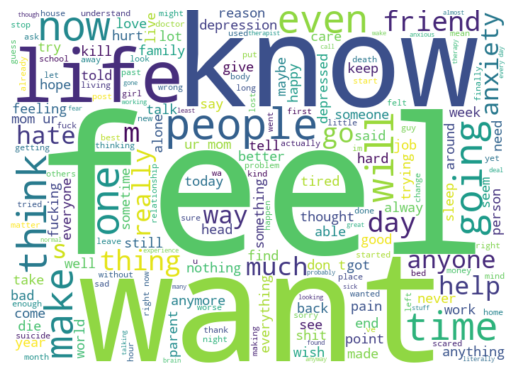

In [3]:
# Wordcloud
text = df['text'].str.cat() # Make the text into one large paragraph
wordcloud = WordCloud(width = 700, height = 500, background_color = 'white').generate(text) # Has built in filter for stop words

# Plot
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

In [4]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/maxmar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

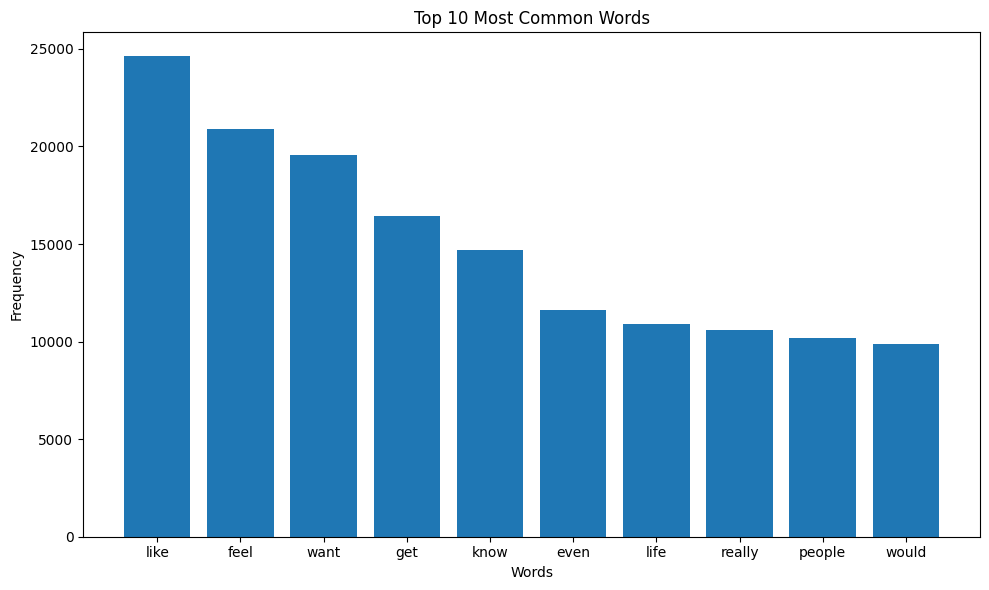

In [5]:
from collections import Counter
from nltk.corpus import stopwords

# Getting most frequent words
def plot_most_freq_words(text, stopwords):
    """
    Function that takes in raw text, cleans it and plots the most frequent words
    """
    
    # Preprocessing text
    text = text.lower()
    words = text.split()
    
    clean_words = []
    for word in words:
        if word not in stopwords:
            clean_words.append(word)

    # Count word frequencies
    word_counts = Counter(clean_words)    
    top_10_words = word_counts.most_common(10)
    word_labels_10 = [word for word, _ in top_10_words]
    word_counts_10 = [count for _, count in top_10_words]
    
    # Plot
    plt.figure(figsize = (10, 6))
    plt.bar(word_labels_10, word_counts_10)
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.title('Top 10 Most Common Words')
    plt.tight_layout()
    plt.show()
    
    # Return counts for all words
    return pd.DataFrame(word_counts.items(), columns = ['Word', 'Count'])

stop_words = set(stopwords.words('english'))    
freq_df = plot_most_freq_words(text, stop_words)

## Data Splits

In [6]:
from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(df['text'], df['status'], test_size = 0.2, 
                                                    stratify = df['status'], random_state = 3)


In [7]:
df['status'].value_counts()


status
Normal        18391
Depression    14506
Suicidal      11212
Anxiety        5503
Name: count, dtype: int64

In [8]:
ytrain.value_counts()

status
Normal        14713
Depression    11605
Suicidal       8969
Anxiety        4402
Name: count, dtype: int64

In [9]:
ytest.value_counts()

status
Normal        3678
Depression    2901
Suicidal      2243
Anxiety       1101
Name: count, dtype: int64

In [10]:
# map emotions
class_map = {'Anxiety': 0, 'Depression': 1, 'Normal': 2, 'Suicidal': 3}
ytrain = ytrain.map(class_map)
ytest = ytest.map(class_map)

## Dumb Baseline

In [ ]:
counts = ytest.value_counts()

# dumb baseline where only the label with maximum frequency is predicted
max_count = counts[counts.index[0]]
total_count = ytest.count()

dumb_prediction_accr = max_count / total_count

print(f"Dumb Baseling Accuracy: {100 * dumb_prediction_accr:.2f}%")

Dumb Baseling Accuracy: 37.07%


## Model Training and Eval Functions

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report


def fit_predict(X_train, X_test, y_train, y_test, vectorizer, model):

    # Fit vectorizer
    X_train = vectorizer.fit_transform(X_train)
    X_test = vectorizer.transform(X_test)
   
    # Model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    cm = confusion_matrix(y_test, y_pred)

    print(classification_report(y_test, y_pred, target_names=['Anxiety', 'Depression', 'Normal', 'Suicidal']))

    return y_pred, y_proba, cm

In [13]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_ovr_roc_curves(y_test, y_proba, classes, class_names, model_name):

    # Invert class_names from {name: number} to {number: name}
    class_names_inv = {v: k for k, v in class_names.items()}

    # Binarize y_test into shape (n_samples, n_classes)
    y_test_bin = label_binarize(y_test, classes=classes)

    fig, ax = plt.subplots(figsize=(8, 6))

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)

        label_name = class_names_inv.get(cls, cls)  # fallback to cls if not found
        ax.plot(fpr, tpr, lw=2, label=f"{label_name} (AUC = {roc_auc:.2f})")

    # Random chance baseline
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random chance")

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"One-vs-Rest ROC Curves - {model_name}")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

## Predictions and Evaluations

In [14]:
# Call the models and vectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
import xgboost as xgb
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer(stop_words = "english")

In [15]:
model_lr = LogisticRegression(random_state = 3, solver='lbfgs')
y_pred_lr, y_proba_lr, cm_lr = fit_predict(Xtrain, Xtest, ytrain, ytest, vect, model_lr)

              precision    recall  f1-score   support

     Anxiety       0.77      0.74      0.75      1101
  Depression       0.68      0.66      0.67      2901
      Normal       0.86      0.94      0.90      3678
    Suicidal       0.66      0.59      0.62      2243

    accuracy                           0.76      9923
   macro avg       0.74      0.73      0.74      9923
weighted avg       0.75      0.76      0.75      9923



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
model_nb = MultinomialNB()
y_pred_nb, y_proba_nb, cm_nb = fit_predict(Xtrain, Xtest, ytrain, ytest, vect, model_nb)

              precision    recall  f1-score   support

     Anxiety       0.70      0.68      0.69      1101
  Depression       0.55      0.72      0.63      2901
      Normal       0.95      0.68      0.79      3678
    Suicidal       0.62      0.68      0.65      2243

    accuracy                           0.69      9923
   macro avg       0.71      0.69      0.69      9923
weighted avg       0.73      0.69      0.70      9923



In [17]:
model_xgb = xgb.XGBClassifier(n_estimators=10000, max_depth=3, learning_rate=0.1, eval_metric = 'mlogloss')
y_pred_xgb, y_proba_xgb, cm_xgb = fit_predict(Xtrain, Xtest, ytrain, ytest, vect, model_xgb)

              precision    recall  f1-score   support

     Anxiety       0.79      0.76      0.77      1101
  Depression       0.70      0.70      0.70      2901
      Normal       0.88      0.93      0.90      3678
    Suicidal       0.69      0.63      0.66      2243

    accuracy                           0.78      9923
   macro avg       0.76      0.76      0.76      9923
weighted avg       0.77      0.78      0.78      9923



### Confusion Matrices

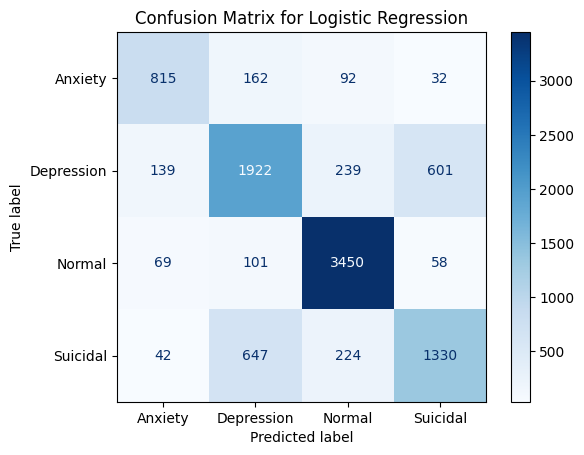

In [18]:
# Confusion Matrix for Logistic Regression
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=class_map)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

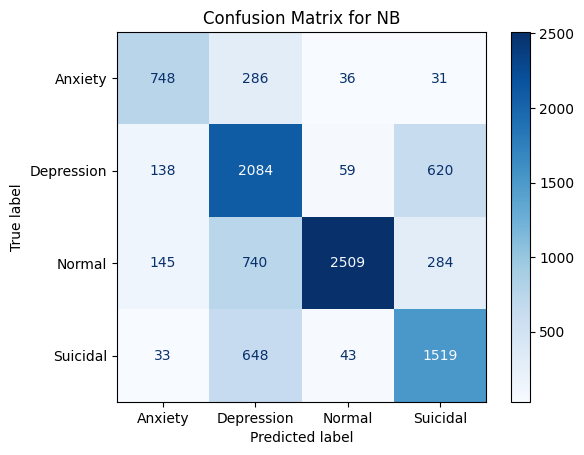

In [19]:
# Confusion Matrix for Naive Bayes
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=class_map)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for NB')
plt.show()

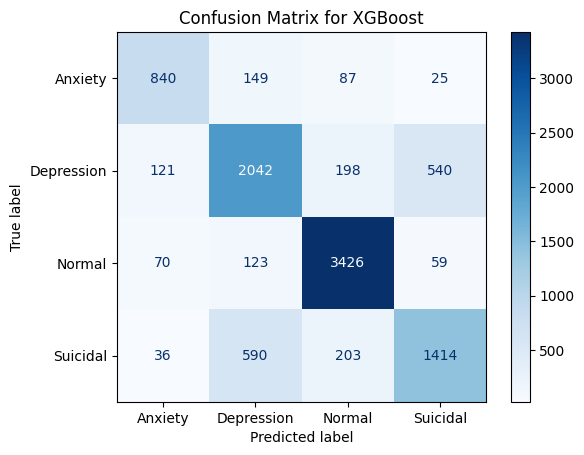

In [20]:
# Confusion Matrix for XGBoost
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=class_map)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for XGBoost')
plt.show()

### ROC Curves

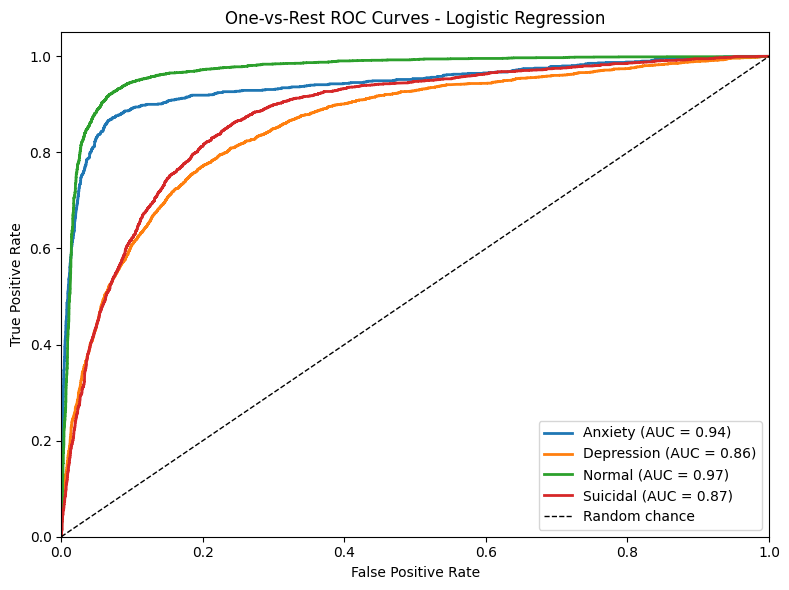

In [21]:
# ROC Curve for Logistic Regression
plot_ovr_roc_curves(ytest, y_proba_lr, classes=model_lr.classes_, class_names = class_map, model_name = 'Logistic Regression')

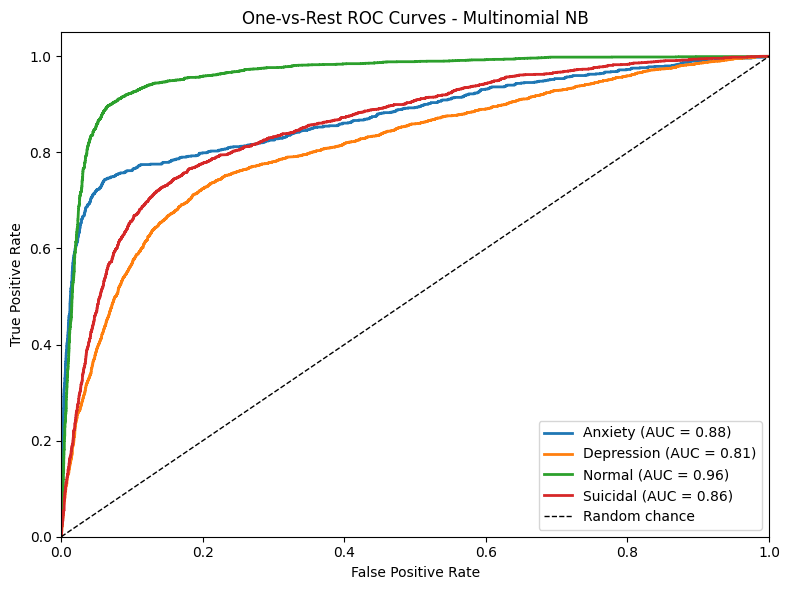

In [22]:
# ROC Curve for Naive Bayes
plot_ovr_roc_curves(ytest, y_proba_nb, classes=model_nb.classes_, class_names = class_map, model_name = 'Multinomial NB')

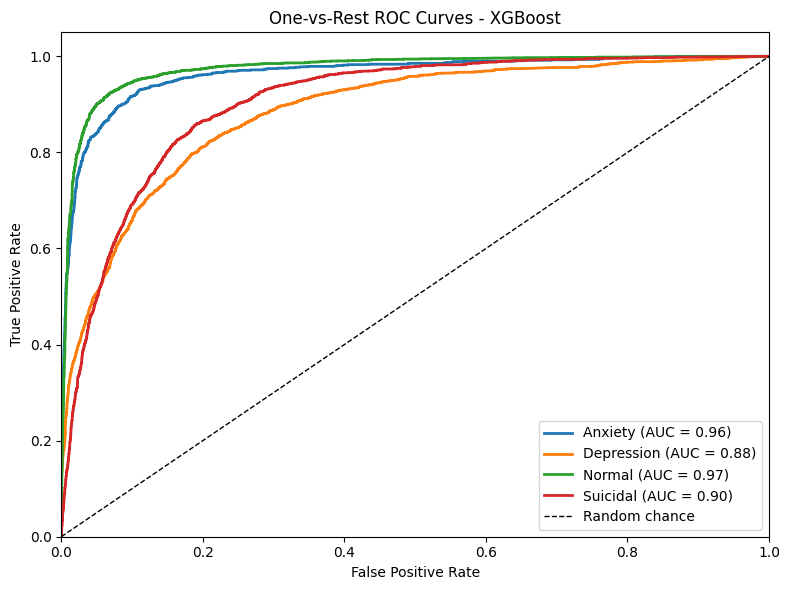

In [23]:
# ROC Curve for XGBoost
plot_ovr_roc_curves(ytest, y_proba_xgb, classes=model_xgb.classes_, class_names = class_map, model_name = 'XGBoost')

In [30]:
# Data frame to compare true label with predicted label
test_df = pd.concat([Xtest, ytest], axis=1)
test_df['Predicted_xgb'] = y_pred_xgb
print(class_map)
pd.set_option('display.max_colwidth', None)
test_df.head(20)


{'Anxiety': 0, 'Depression': 1, 'Normal': 2, 'Suicidal': 3}


,text,status,Predicted_xgb
42163,"I don’t know if I’m depressed or a normal teen I feel lonely, sad, and I want to die on a daily basis. I don’t know if I’m depressed or just doing normal teen stuff. I hate my family, because my sister and my mom always team up on me when I just want to do the one thing that makes me happy which is play video games with my friends. I worked all summer to buy a pc and they made me put it in the middle of the house where everyone can hear them screaming. I want to kill myself. And when I try to tell my family how I feel my mom says if I don’t like it I should move out. But if I move out I don’t know who to go to.",2,1
48672,"All my friends are busy or asleep, talk to me Yeah....thats it, im alt....so das cool....talk to me pls",2,2
30317,"mmm OJ, scrambled eggs w/ cheese and toast GILMOREGIRLS TOO! ahhh. this day is amazing.. now if i could only get the dryer to work.",2,2
34200,koschbob jonathanhatami the great depression saw crime spike to it highest point in the u especially in regard to theft when job don t pay enough and cost keep rising people who aren t able to lean on supporter or debt resort to crime in order to make it or fall into homelessness amp squalor,1,1
17622,"So, basic information, I have tried to suicide 3 times, 4 years ago, since then i worked on a plan to do it right, and everything is done, even the exact date.Now, you see, nobody knows about this, because i am very good at not showing emotions, and i try to look and be as strong as there can one be, phisically and mentally, and unstopable force and an immovable object, and this works, as I have no regard for my safety, and so i make my family proud, my friends have fun, and I am a very loving and protective boyfriend (single at the moment), aside from this, i study to become a neurosurgeon.I know very well this is not even close to what others are going through, but in around half a year, my suicide should take place, as I am no longer able to keep up, maybe i can last a couple of weeks more.I have to ask if there is any way to keep going, aside form alcoohol, because i already drink daily, and aside from love and care, because that is impossible, any suggestion is good, i am open minded. Long story short",3,1
10050,I hear some people say that you pass put and do not feel a thing. Then you have the others who say because it is not helium you have seizures and foam at the mouth for ten minutes before dying. Which is it? I want the truth dammit So is carbon monoxide painful or not? For science,3,3
31959,hi friend i stopped using weed and caffeine and day ago respectively and i ve seen my anxiety increase exponentially obviously i used both to kinda suppress my normal anxiety but now i m going au natural and a you can tell it s not going ideally but i m happy to have made the choice i did i have felt a weird knot sensation in the right upper side of my abdomen feel like it s right under my rib cage and occasional pain throughout my digestive system i ve been constipated for about day too i know so much info and while i m able to still go i still feel a discomfort in my side like someone took a five pound weight and just placed it on the side of me is this normal with anxiety i haven t started any antidepressant i ve been prescribed because i want to see how naturally i can do this but my mind is telling me withdrawal and to just be patient but i don t want to be too patient in case it s something that i should have a doctor check out thought,1,0
39440,The sad truth is . If i dont text people first ill never hear from them again It happens every single time. People tell me that they care about me and they’re my friend and yet my phone is so dry and this is not an exageration. I can feel myself dying from the loneliness,0,1
9355,"Sounds dramatic but my thick long hair is the only thing I had going for me and I am now hideous, Cynthia the doll has more hair on her head than what I am left with. cannot stop crying, dad keeps giv